# GEV Bayesian Flood Frequency Analysis

This notebook demonstrates fitting a single-population Generalised Extreme Value (GEV) distribution to an Annual Maximum Series (AMS) using PyMC.

In [1]:
import pandas as pd
import numpy as np
import arviz as az
import matplotlib.pyplot as plt
from flood_ffa.data.bom import load_ams, get_flow_series
from flood_ffa.gev.fit import fit_gev
from flood_ffa.gev.plots import plot_trace, plot_corner, plot_return_levels

## Load AMS Data

We load the 55-year gauge record (1970-2024). Note the significant outlier in 2021.

In [2]:
df = load_ams("../data/AMS.csv")
flows = get_flow_series(df)
print(f"Number of observations: {len(flows)}")
print(f"Maximum flow: {flows.max()} m3/s (Year: {flows.idxmax()})")
flows.tail()

Number of observations: 55
Maximum flow: 121.9 m3/s (Year: 2021)


year
2020     15.6
2021    121.9
2022     48.3
2023     25.4
2024     13.5
Name: flow_m3s, dtype: float64

## Bayesian Inference

We fit the GEV model using NUTS sampling. The prior for the shape parameter (xi) is centred at 0 (Gumbel).

In [3]:
# Fit the GEV model
# draws=2000, tune=1000 is usually sufficient for this single-population model
idata_gev = fit_gev(flows, draws=2000, tune=1000)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma, xi]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 33 seconds.
There were 26 divergences after tuning. Increase `target_accept` or reparameterize.


## Posterior Diagnostics

We review the trace plots to ensure good mixing and convergence.

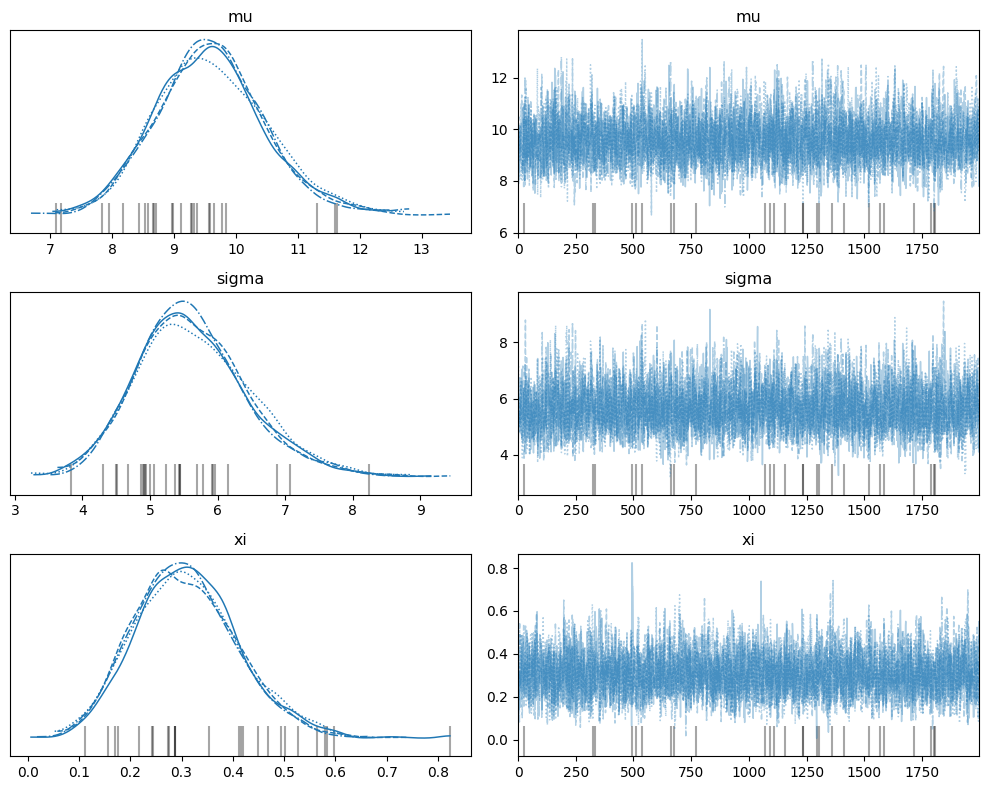

In [4]:
plot_trace(idata_gev);
plt.show()

## Posterior Correlations

The corner plot shows the joint distributions and correlations between mu, sigma, and xi.

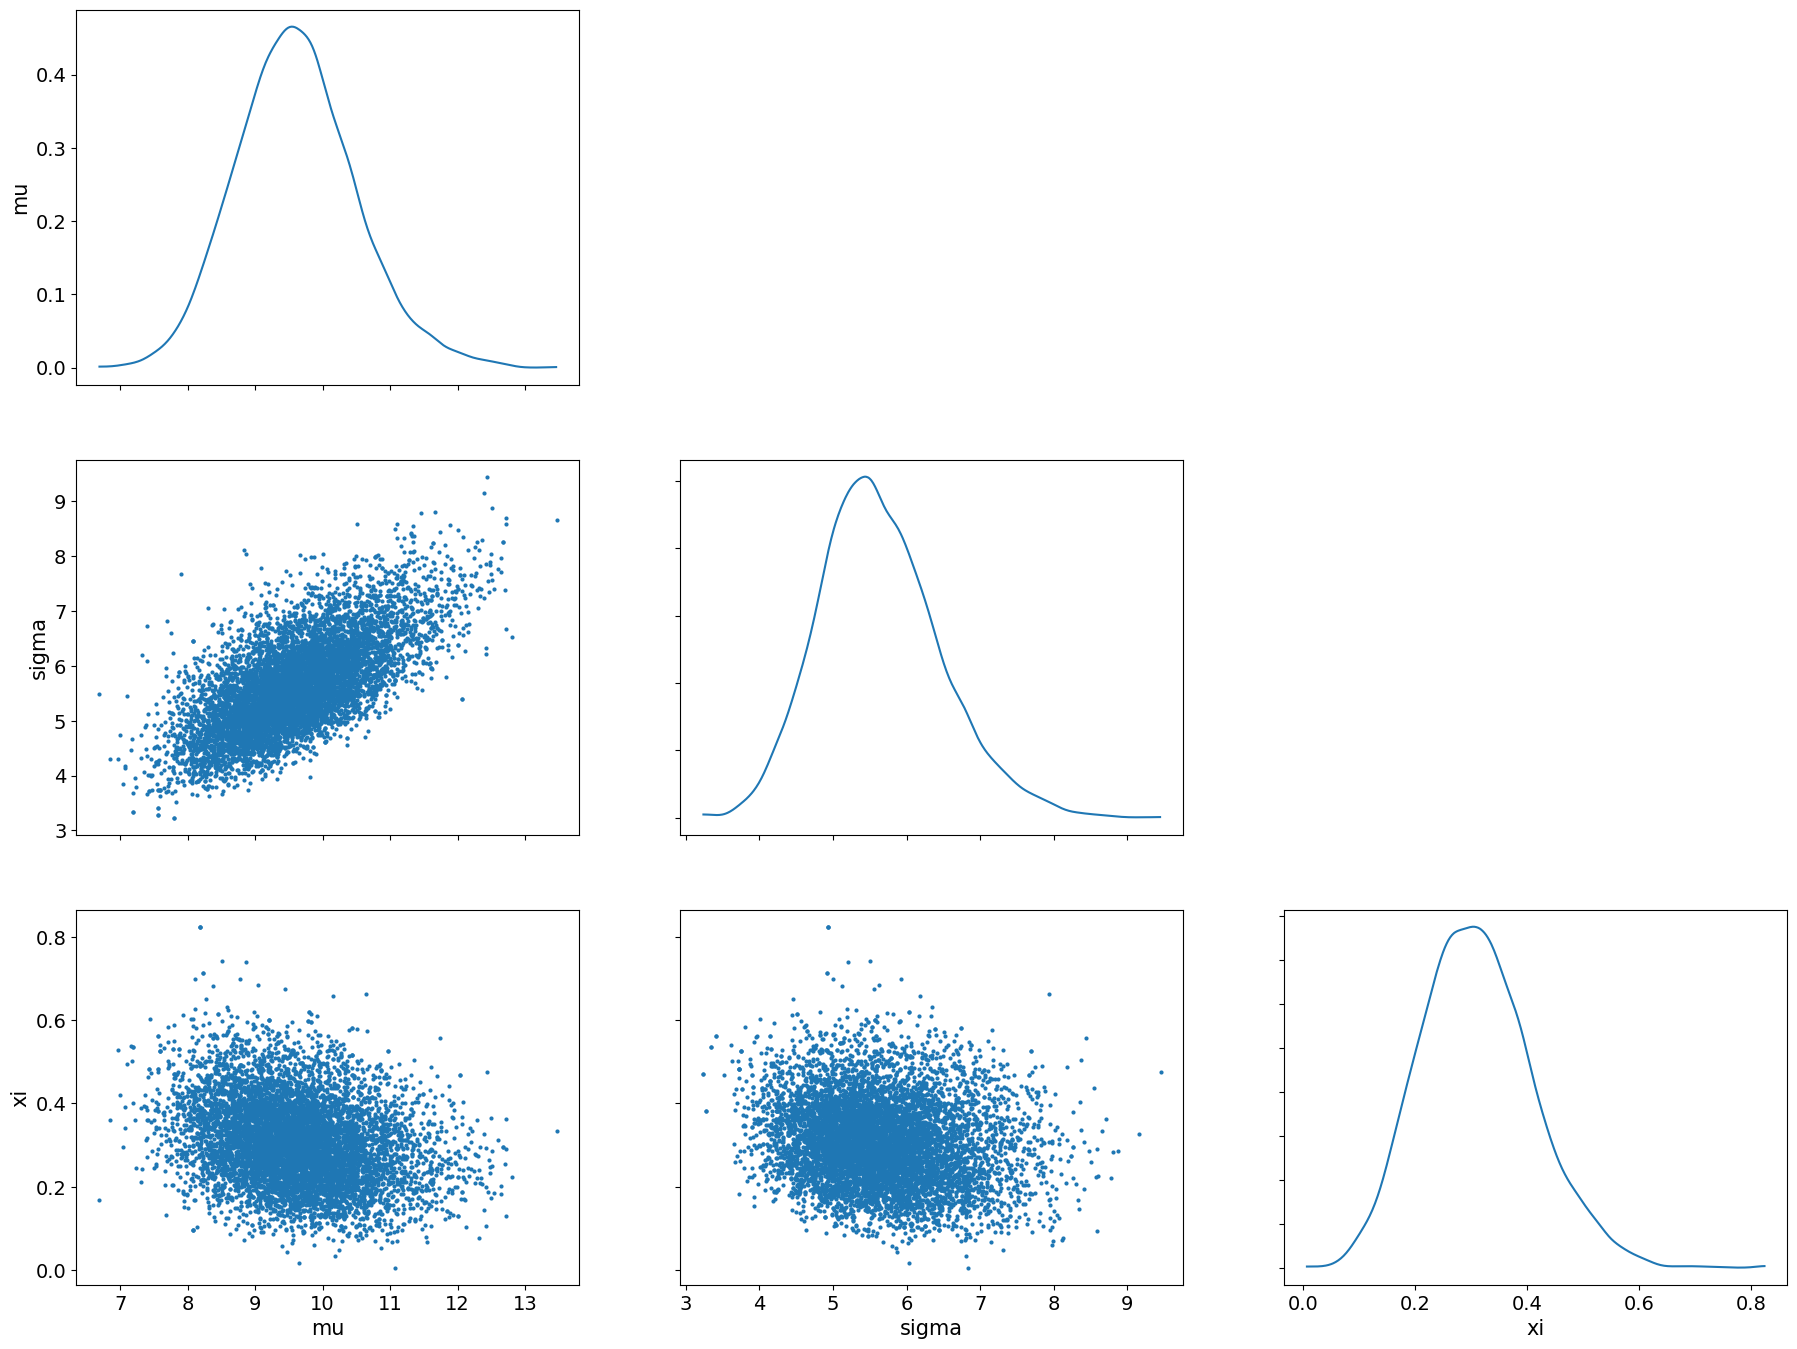

In [5]:
plot_corner(idata_gev);
plt.show()

## Flood Frequency Curve

We plot the frequency curve on a probability scale with 94% HDI uncertainty bands.

E:\GitHub\pyFloodExtremes\src\flood_ffa\gev\plots.py:68: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_chains = idata.posterior.dims['chain']
E:\GitHub\pyFloodExtremes\src\flood_ffa\gev\plots.py:69: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_draws = idata.posterior.dims['draw']


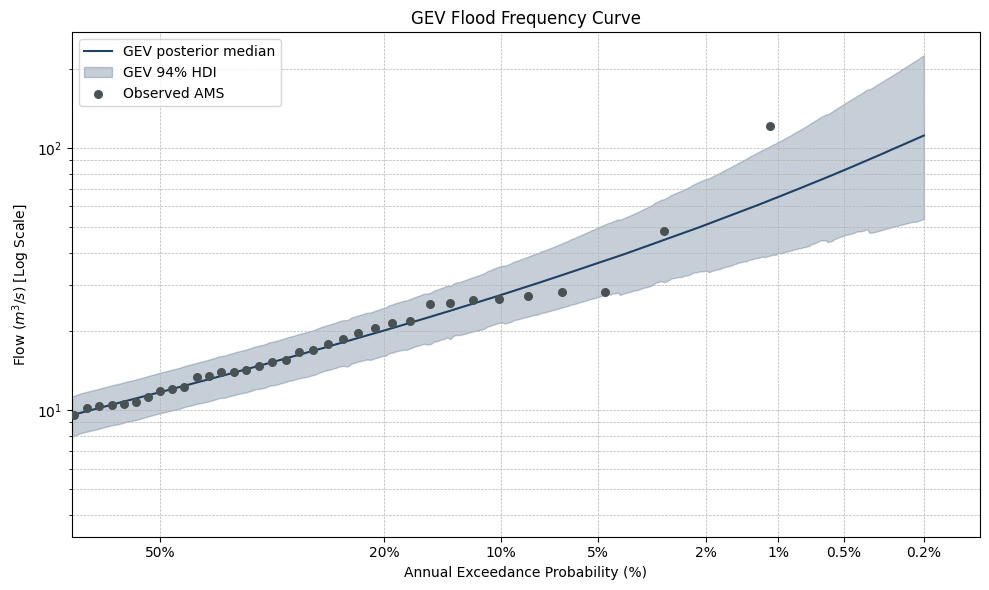

In [6]:
plot_return_levels(idata_gev, flows);
plt.show()

## Parameter Summary

Summary statistics for the posterior distributions.

In [7]:
az.summary(idata_gev, hdi_prob=0.94)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,9.600,0.884,7.902,11.237,0.015,0.011,3445.0,3828.0,1.0
xi,0.310,0.101,0.124,0.498,0.002,0.001,4148.0,3500.0,1.0
sigma,5.632,0.823,4.132,7.211,0.013,0.010,3762.0,4003.0,1.0
